# 01. Load, QC, and merge Day 0 Insm1 scRNA-seq data

This notebook reads the `Gene Expression` features from the multiome 10x H5 files listed in `config/samples.tsv`, computes QC metrics, filters cells with the same thresholds used in the retina TH1/TH2 workflow, and saves a merged AnnData object.

In [1]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)
sns.set_style("whitegrid")

/var/folders/bw/h94700p51374zgrbzwg8hrbh0000gn/T/ipykernel_42078/828049319.py:10: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)


In [2]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "config" / "samples.tsv").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not find day0_insm1_scrna project root")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SAMPLES_TSV = PROJECT_ROOT / "config" / "samples.tsv"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
QC_DIR = PROJECT_ROOT / "results" / "qc"

INTERIM_DIR.mkdir(parents=True, exist_ok=True)
QC_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Sample sheet: {SAMPLES_TSV}")

Project root: /Users/louis/Desktop/lab/code/scrna/day0_insm1_scrna
Sample sheet: /Users/louis/Desktop/lab/code/scrna/day0_insm1_scrna/config/samples.tsv


In [3]:
samples = pd.read_csv(SAMPLES_TSV, sep="\t")
samples

,sample_id,day,genotype,condition,feature_matrix_h5
0,TH1,Day0,Chx10Cre,Control,/Users/louis/Desktop/lab/code/r_demo/Sample_15...
1,TH2,Day0,Chx10Cre_Insm1_KO,Insm1_KO,/Users/louis/Desktop/lab/code/r_demo/Sample_15...


## Load Gene Expression matrices

`sc.read_10x_h5(..., gex_only=True)` reads only the RNA/Gene Expression features from the multiome H5 files and excludes ATAC peaks.

In [4]:
adatas = []

for row in samples.itertuples(index=False):
    h5_path = Path(row.feature_matrix_h5)
    adata = sc.read_10x_h5(h5_path, gex_only=True)
    adata.var_names_make_unique()
    adata.obs_names_make_unique()
    adata.obs["sample_id"] = row.sample_id
    adata.obs["day"] = row.day
    adata.obs["genotype"] = row.genotype
    adata.obs["condition"] = row.condition
    adata.obs["feature_matrix_h5"] = str(h5_path)
    adatas.append(adata)
    print(f"{row.sample_id}: {adata.n_obs} cells x {adata.n_vars} genes")

/Users/louis/Desktop/lab/code/scrna/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1880: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


TH1: 17653 cells x 33696 genes
TH2: 18375 cells x 33696 genes


/Users/louis/Desktop/lab/code/scrna/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1880: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## QC metrics

In [5]:
for adata in adatas:
    adata.var["mt"] = adata.var_names.str.lower().str.startswith("mt-")
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, percent_top=[50, 100, 200, 500], log1p=True)

qc_summary = pd.concat(
    [
        adata.obs[["sample_id", "total_counts", "n_genes_by_counts", "pct_counts_mt"]]
        for adata in adatas
    ],
    ignore_index=True,
)
qc_summary.groupby("sample_id").agg(["median", "mean"]).round(2)

total_counts              n_genes_by_counts          pct_counts_mt  \
                median         mean            median     mean        median   
sample_id                                                                      
TH1             3775.0  4989.529785            2091.0  2389.76          0.75   
TH2             3653.0  4610.779785            2081.0  2326.84          1.55   

                 
           mean  
sample_id        
TH1        1.30  
TH2        2.21

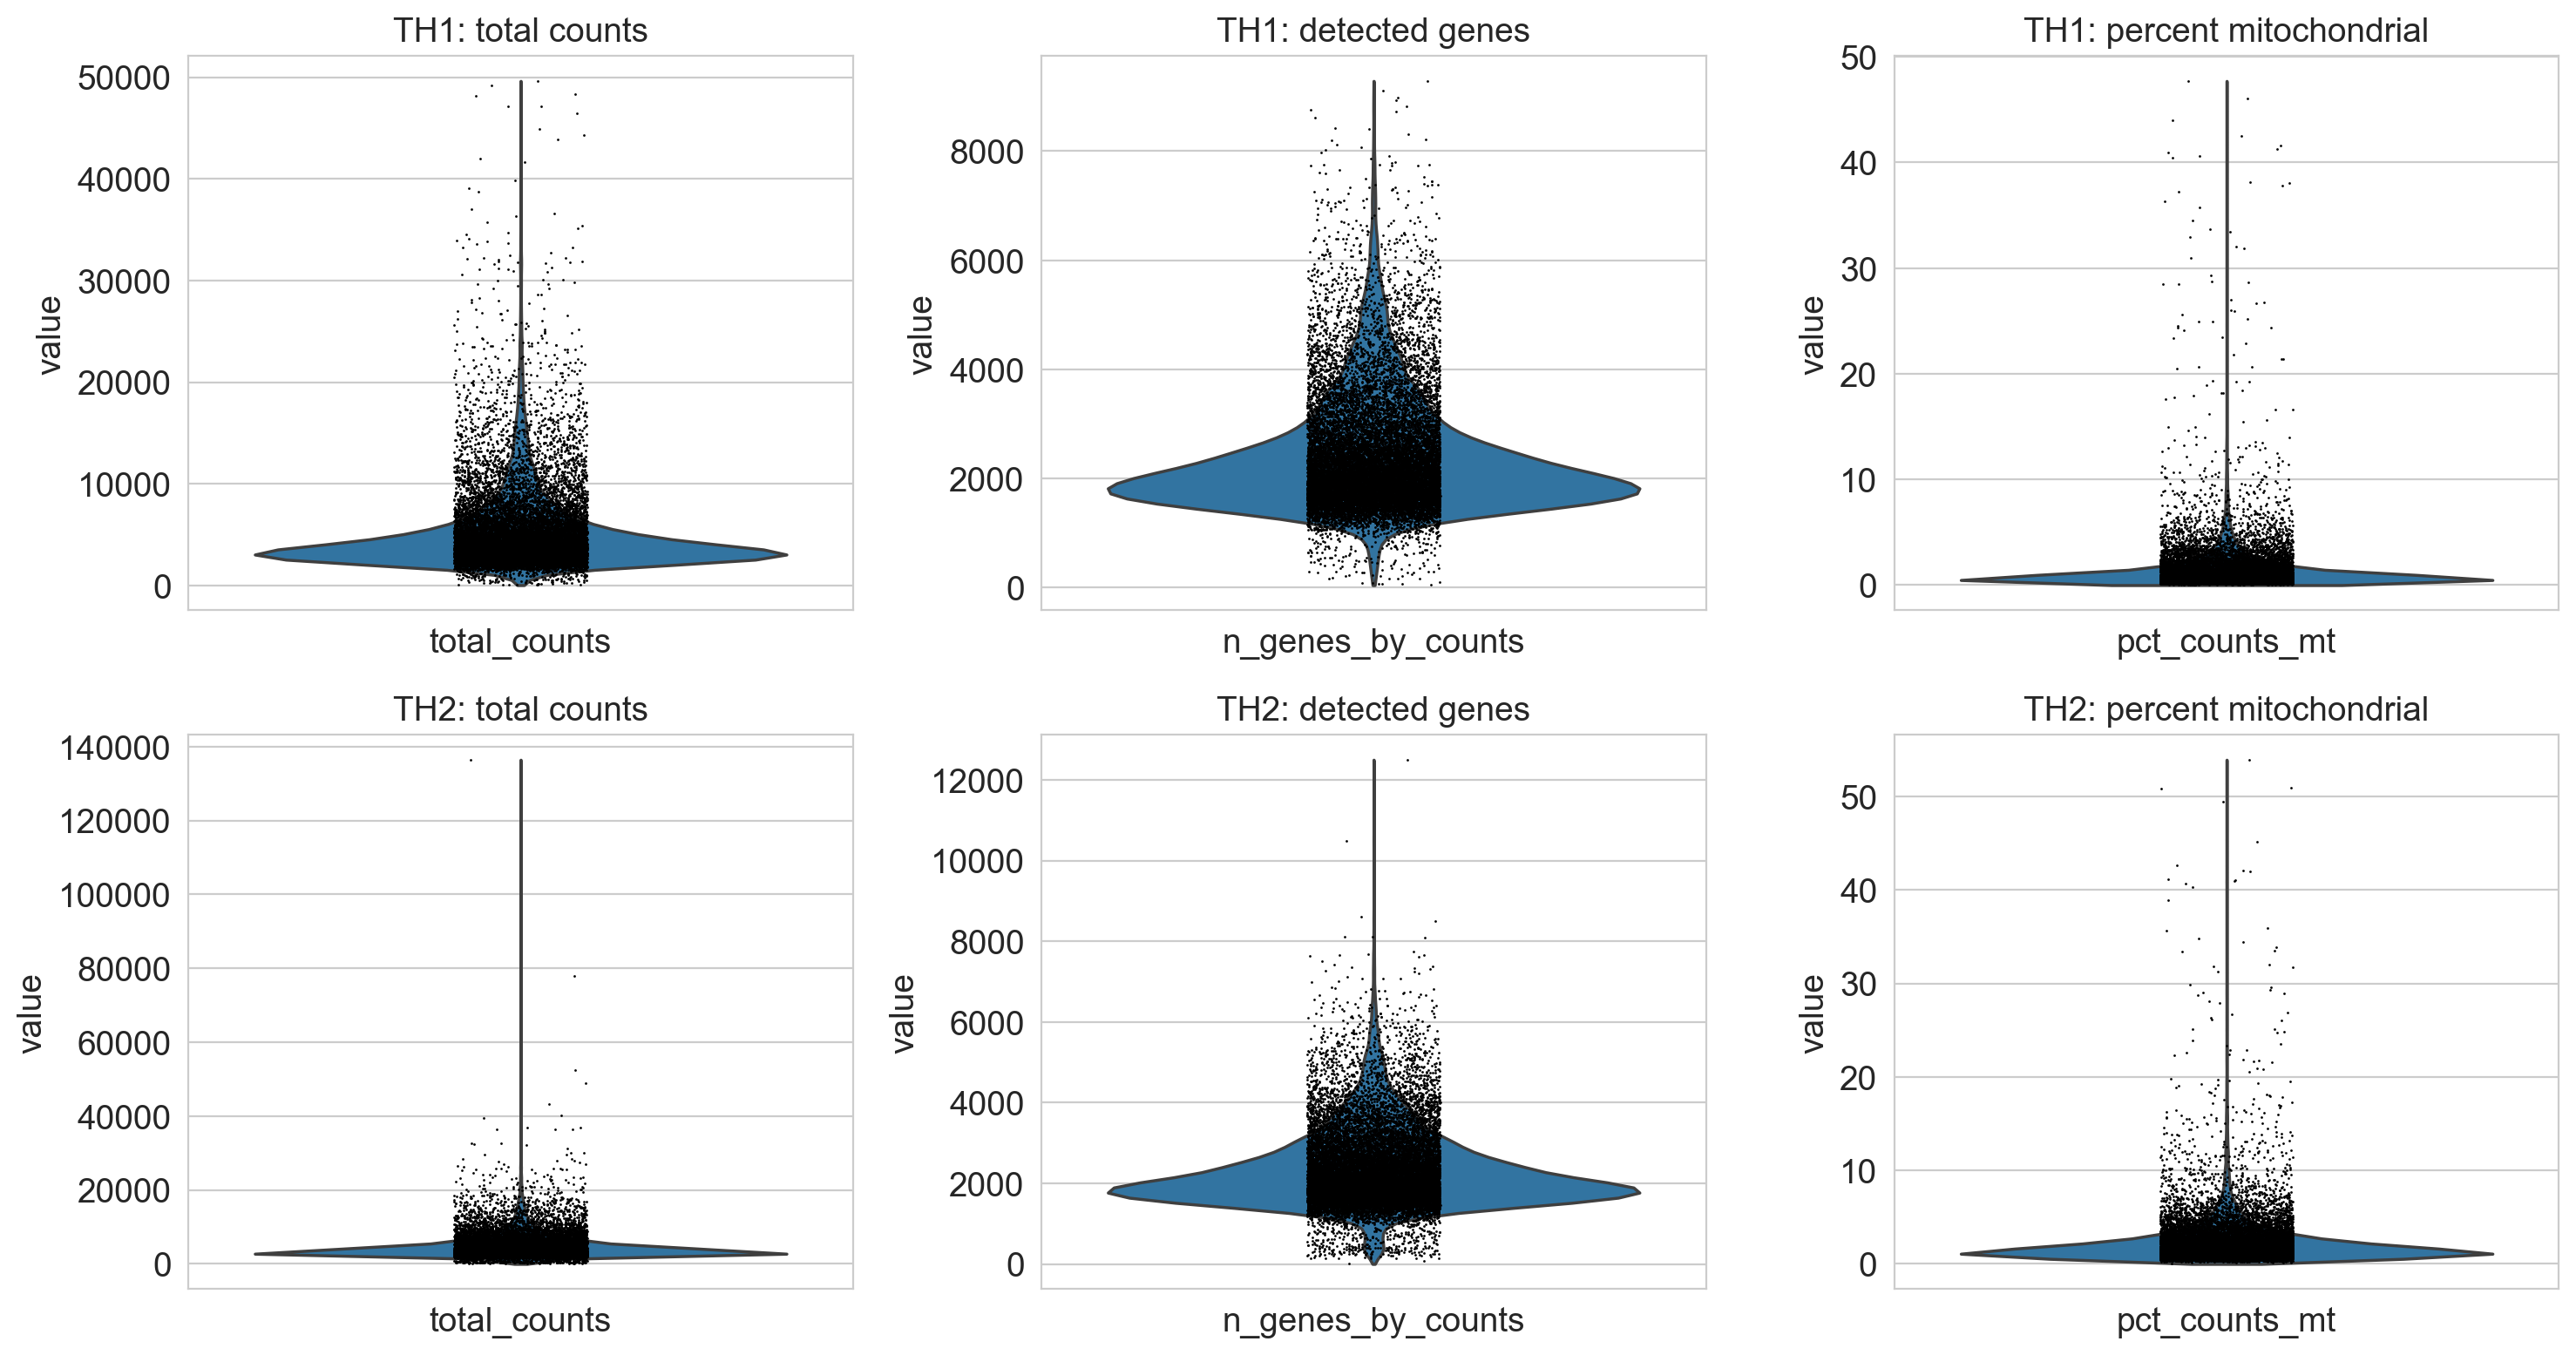

In [6]:
fig, axes = plt.subplots(len(adatas), 3, figsize=(15, 4 * len(adatas)))
if len(adatas) == 1:
    axes = [axes]

for i, adata in enumerate(adatas):
    sample_id = adata.obs["sample_id"].iloc[0]
    sc.pl.violin(adata, "total_counts", ax=axes[i][0], show=False)
    sc.pl.violin(adata, "n_genes_by_counts", ax=axes[i][1], show=False)
    sc.pl.violin(adata, "pct_counts_mt", ax=axes[i][2], show=False)
    axes[i][0].set_title(f"{sample_id}: total counts")
    axes[i][1].set_title(f"{sample_id}: detected genes")
    axes[i][2].set_title(f"{sample_id}: percent mitochondrial")

plt.tight_layout()
plt.show()

## Filter cells

These thresholds match the previous retina TH1/TH2 workflow. Review the plots before treating them as final.

In [7]:
FILTERS = {
    "min_genes": 800,
    "max_genes": 8000,
    "min_counts": 1200,
    "max_counts": 30000,
    "max_mt_pct": 10,
}
FILTERS

{'min_genes': 800,
 'max_genes': 8000,
 'min_counts': 1200,
 'max_counts': 30000,
 'max_mt_pct': 10}

In [8]:
filtered_adatas = []
filter_stats = []

for adata in adatas:
    keep = (
        (adata.obs["n_genes_by_counts"] >= FILTERS["min_genes"])
        & (adata.obs["n_genes_by_counts"] <= FILTERS["max_genes"])
        & (adata.obs["total_counts"] >= FILTERS["min_counts"])
        & (adata.obs["total_counts"] <= FILTERS["max_counts"])
        & (adata.obs["pct_counts_mt"] < FILTERS["max_mt_pct"])
    )
    filtered = adata[keep].copy()
    sample_id = adata.obs["sample_id"].iloc[0]
    filtered_adatas.append(filtered)
    filter_stats.append({
        "sample_id": sample_id,
        "condition": adata.obs["condition"].iloc[0],
        "cells_before": adata.n_obs,
        "cells_after": filtered.n_obs,
        "cells_removed": adata.n_obs - filtered.n_obs,
        "fraction_retained": round(filtered.n_obs / adata.n_obs, 4),
    })

filter_stats_df = pd.DataFrame(filter_stats)
filter_stats_df

,sample_id,condition,cells_before,cells_after,cells_removed,fraction_retained
0,TH1,Control,17653,17344,309,0.9825
1,TH2,Insm1_KO,18375,17868,507,0.9724


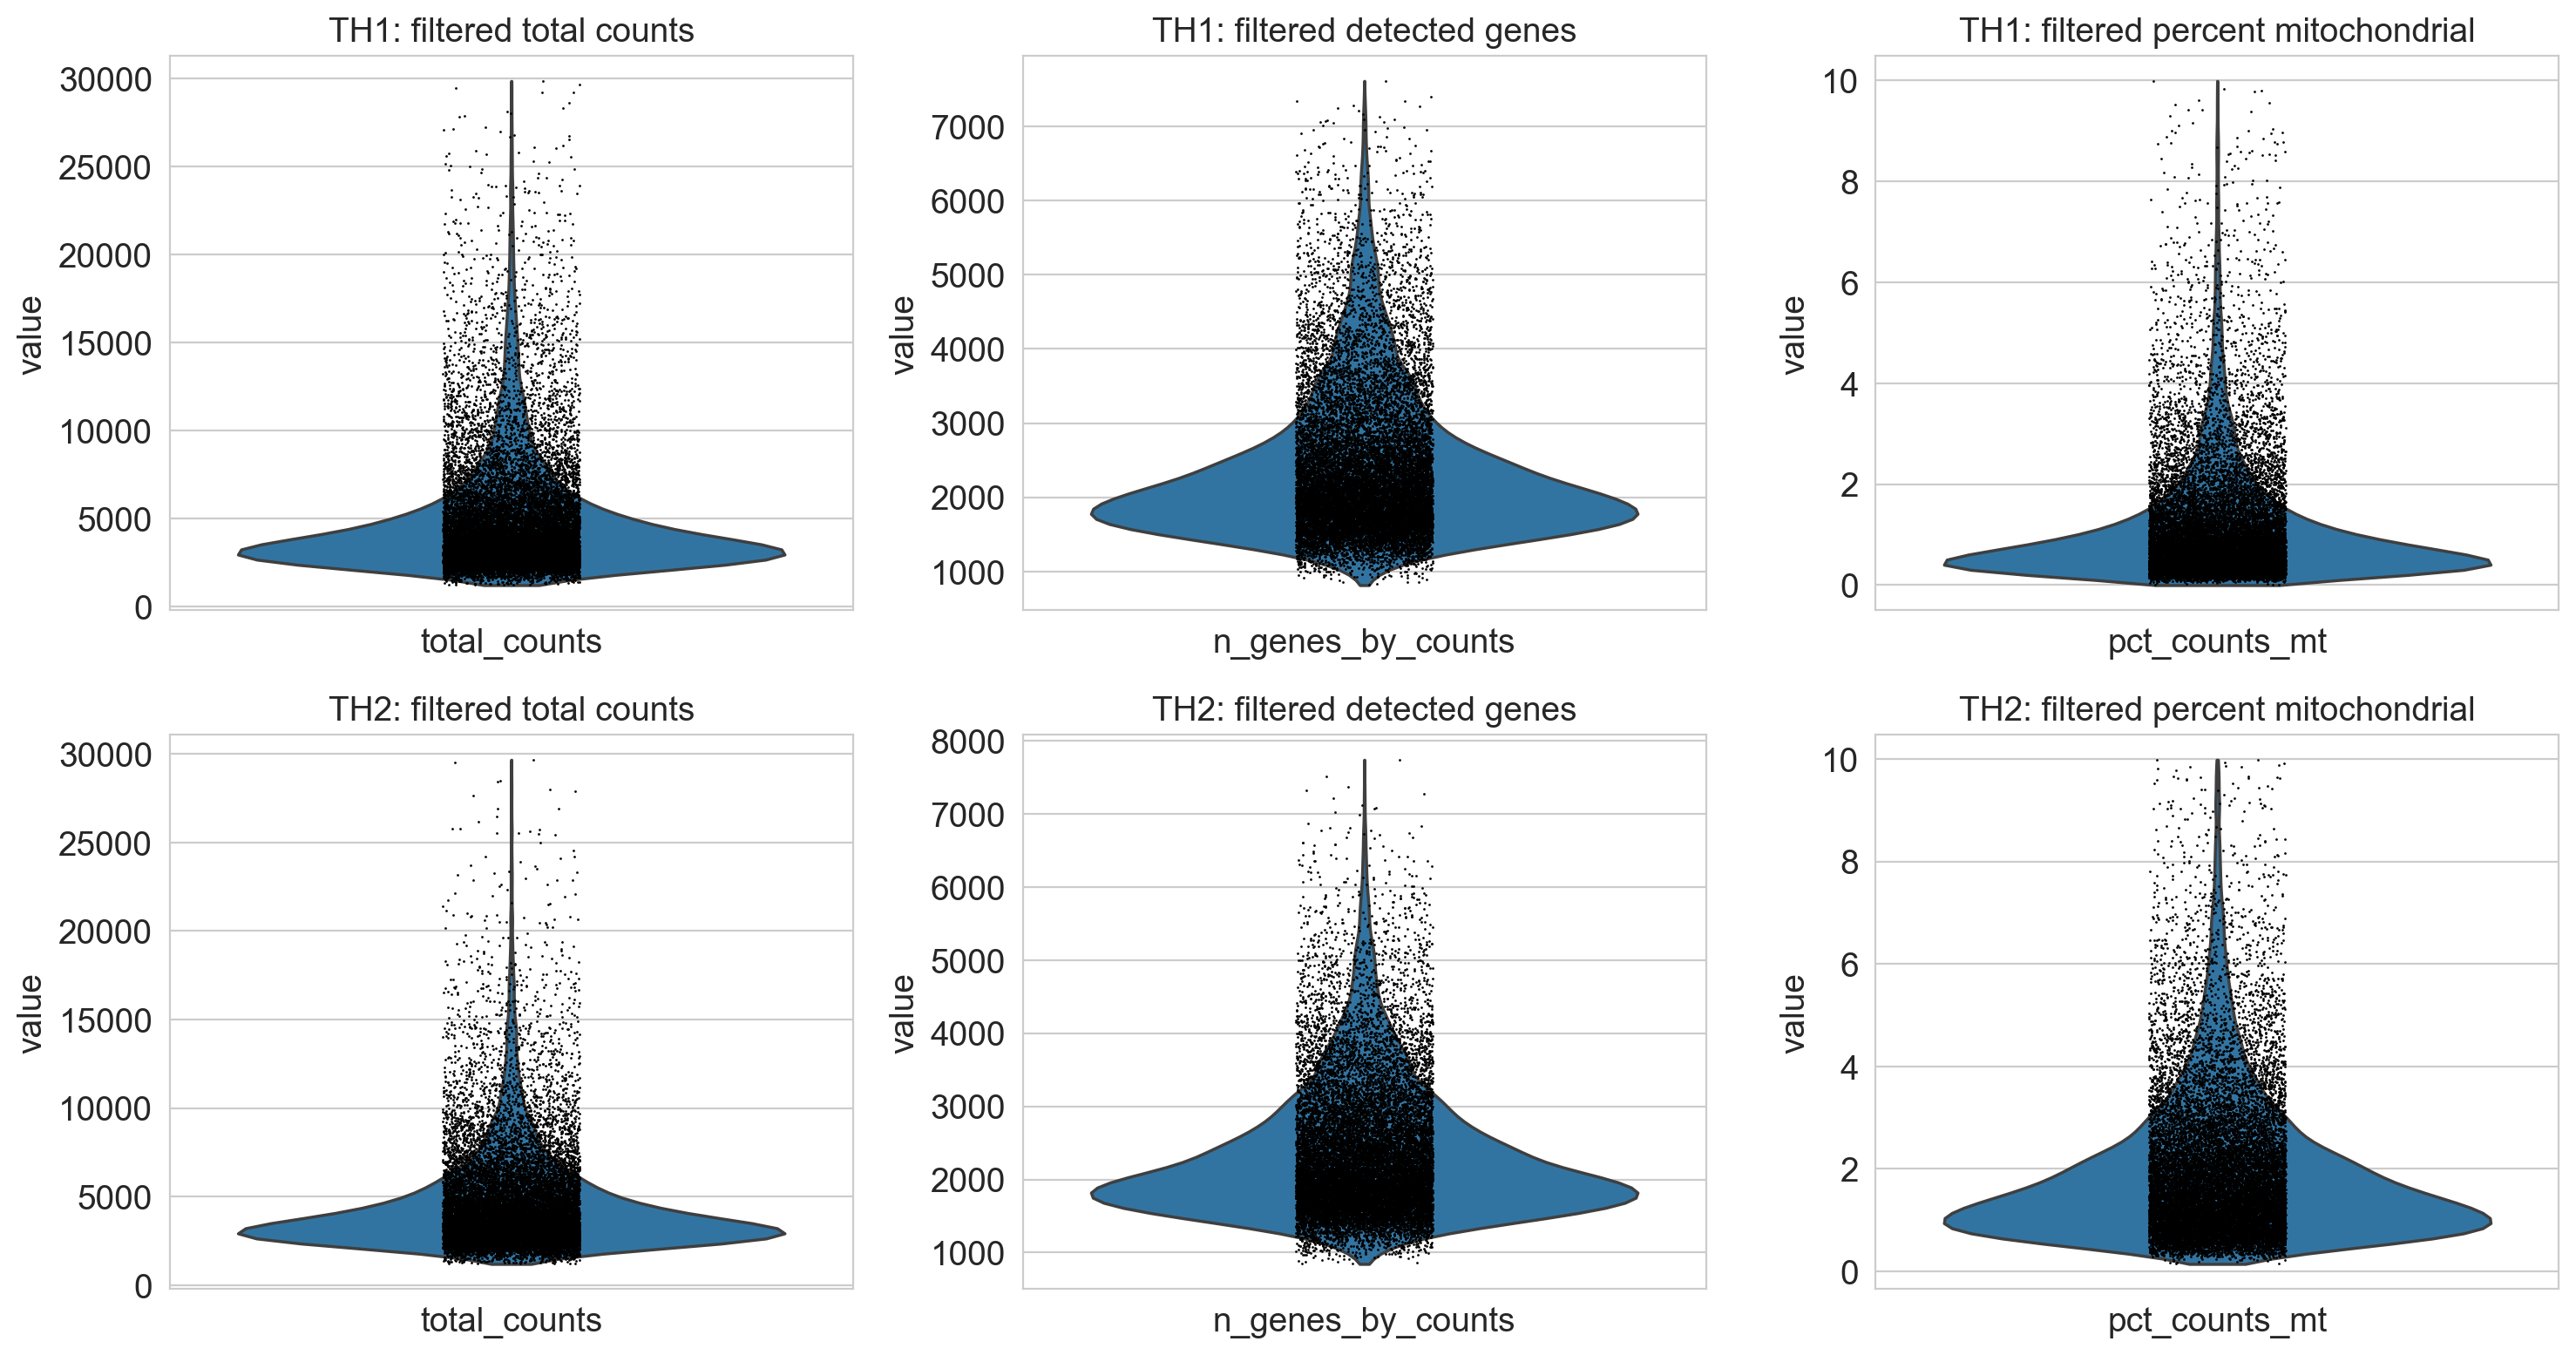

In [9]:
fig, axes = plt.subplots(len(filtered_adatas), 3, figsize=(15, 4 * len(filtered_adatas)))
if len(filtered_adatas) == 1:
    axes = [axes]

for i, adata in enumerate(filtered_adatas):
    sample_id = adata.obs["sample_id"].iloc[0]
    sc.pl.violin(adata, "total_counts", ax=axes[i][0], show=False)
    sc.pl.violin(adata, "n_genes_by_counts", ax=axes[i][1], show=False)
    sc.pl.violin(adata, "pct_counts_mt", ax=axes[i][2], show=False)
    axes[i][0].set_title(f"{sample_id}: filtered total counts")
    axes[i][1].set_title(f"{sample_id}: filtered detected genes")
    axes[i][2].set_title(f"{sample_id}: filtered percent mitochondrial")

plt.tight_layout()
plt.show()

## Merge and save

In [10]:
adata_merged = ad.concat(
    filtered_adatas,
    label="sample_id",
    keys=[adata.obs["sample_id"].iloc[0] for adata in filtered_adatas],
    join="outer",
    merge="same",
    index_unique="-",
)

for col in ["sample_id", "day", "genotype", "condition"]:
    adata_merged.obs[col] = adata_merged.obs[col].astype("category")

adata_merged.layers["counts"] = adata_merged.X.copy()
adata_merged

AnnData object with n_obs × n_vars = 35212 × 33696
    obs: 'sample_id', 'day', 'genotype', 'condition', 'feature_matrix_h5', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt'
    layers: 'counts'

In [11]:
filter_stats_df.to_csv(QC_DIR / "01_filter_summary.csv", index=False)
adata_merged.write(INTERIM_DIR / "01_qc_merged.h5ad")

print(f"Saved filter summary: {QC_DIR / '01_filter_summary.csv'}")
print(f"Saved merged AnnData: {INTERIM_DIR / '01_qc_merged.h5ad'}")

Saved filter summary: /Users/louis/Desktop/lab/code/scrna/day0_insm1_scrna/results/qc/01_filter_summary.csv
Saved merged AnnData: /Users/louis/Desktop/lab/code/scrna/day0_insm1_scrna/data/interim/01_qc_merged.h5ad
